# Model Validation — Quantile Calibration

This notebook validates that the trained quantile regressor is well-calibrated
on held-out data.

## What does calibration mean here?

For a quantile regressor to be useful, its predictions must be statistically
consistent with observed outcomes:

- The predicted **q10** should be exceeded by ~10% of actual prices
- The predicted **q50** should be exceeded by ~50% of actual prices
- The predicted **q90** should be exceeded by ~90% of actual prices

A model that says "q50 = 10,000" but is only beaten by 30% of real prices is
systematically overestimating the market — that would lead to wrong positioning
decisions downstream.

## Two checks

1. **Quantile bucket distribution** — how many observations fall *between*
   consecutive quantile predictions? A well-calibrated model gives roughly
   equal bars (uniform distribution).

2. **Cumulative calibration curve** — the fraction of observations falling
   *below* each predicted quantile should hug the diagonal.

In [1]:
import sys
sys.path.insert(0, '../')

import random
import joblib

import pandas as pd
import numpy as np
from plotnine import *

pd.set_option('display.max_columns', 100)

## 1. Load Data and Model

In [2]:
df = pd.read_csv('../data/train_data.csv')

# Same split used during training
def splitter(df, frac=0.7, seed=42):
    quote_ids = df['quote_id'].unique().tolist()
    rng = random.Random(seed)
    train_ids = set(rng.sample(quote_ids, int(len(quote_ids) * frac)))
    return df[df['quote_id'].isin(train_ids)], df[~df['quote_id'].isin(train_ids)]

_, X_test = splitter(df)
y_test = X_test['target_price'].values

model = joblib.load('../models/model.pkl')

print(f"Test set : {X_test.shape[0]:,} rows ({X_test['quote_id'].nunique():,} quotes)")

Test set : 1,500 rows (300 quotes)


## 2. Generate Quantile Predictions

In [3]:
alphas = np.arange(0.05, 1.0, 0.05)   # q5, q10, ..., q95
q_labels = [f'q{int(a * 100)}' for a in alphas]

preds = model.predict(X_test)          # shape: (n_test, 19)
preds_df = pd.DataFrame(preds, columns=q_labels, index=X_test.index)

print(f"Prediction matrix: {preds.shape}  (observations × quantiles)")
pd.DataFrame(preds, columns=q_labels).describe().round(0)

Prediction matrix: (1500, 19)  (observations × quantiles)


,q5,q10,q15,q20,q25,q30,q35,q40,q45,q50,q55,q60,q65,q70,q75,q80,q85,q90,q95
count,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0
mean,7991.0,8503.0,8853.0,9142.0,9421.0,9671.0,9889.0,10123.0,10361.0,10590.0,10802.0,11009.0,11242.0,11498.0,11765.0,12075.0,12447.0,12966.0,13637.0
std,1778.0,1989.0,2127.0,2234.0,2324.0,2392.0,2446.0,2501.0,2566.0,2629.0,2678.0,2718.0,2767.0,2810.0,2851.0,2926.0,2974.0,2998.0,3010.0
min,3815.0,3943.0,4175.0,4256.0,4578.0,4588.0,4626.0,4642.0,4659.0,4698.0,4780.0,4868.0,4918.0,5013.0,5197.0,5334.0,5594.0,6161.0,6510.0
25%,6616.0,6938.0,7223.0,7446.0,7666.0,7848.0,8067.0,8253.0,8420.0,8641.0,8807.0,9011.0,9220.0,9424.0,9648.0,9906.0,10289.0,10787.0,11460.0
50%,7820.0,8294.0,8612.0,8834.0,9124.0,9382.0,9568.0,9791.0,10021.0,10282.0,10484.0,10686.0,10907.0,11213.0,11452.0,11770.0,12232.0,12790.0,13446.0
75%,9322.0,9957.0,10356.0,10657.0,10956.0,11221.0,11455.0,11768.0,12001.0,12234.0,12458.0,12616.0,12902.0,13197.0,13514.0,13850.0,14281.0,14823.0,15381.0
max,12394.0,14357.0,15930.0,16124.0,17168.0,17888.0,18372.0,18458.0,19485.0,19818.0,19977.0,20558.0,20566.0,20901.0,21294.0,22632.0,22731.0,23729.0,24900.0


## 3. Quantile Bucket Distribution

For each observation, find the highest quantile whose predicted value is still
below the actual price. This tells us which bucket the observation falls into.
A perfectly calibrated model produces a uniform distribution across buckets.

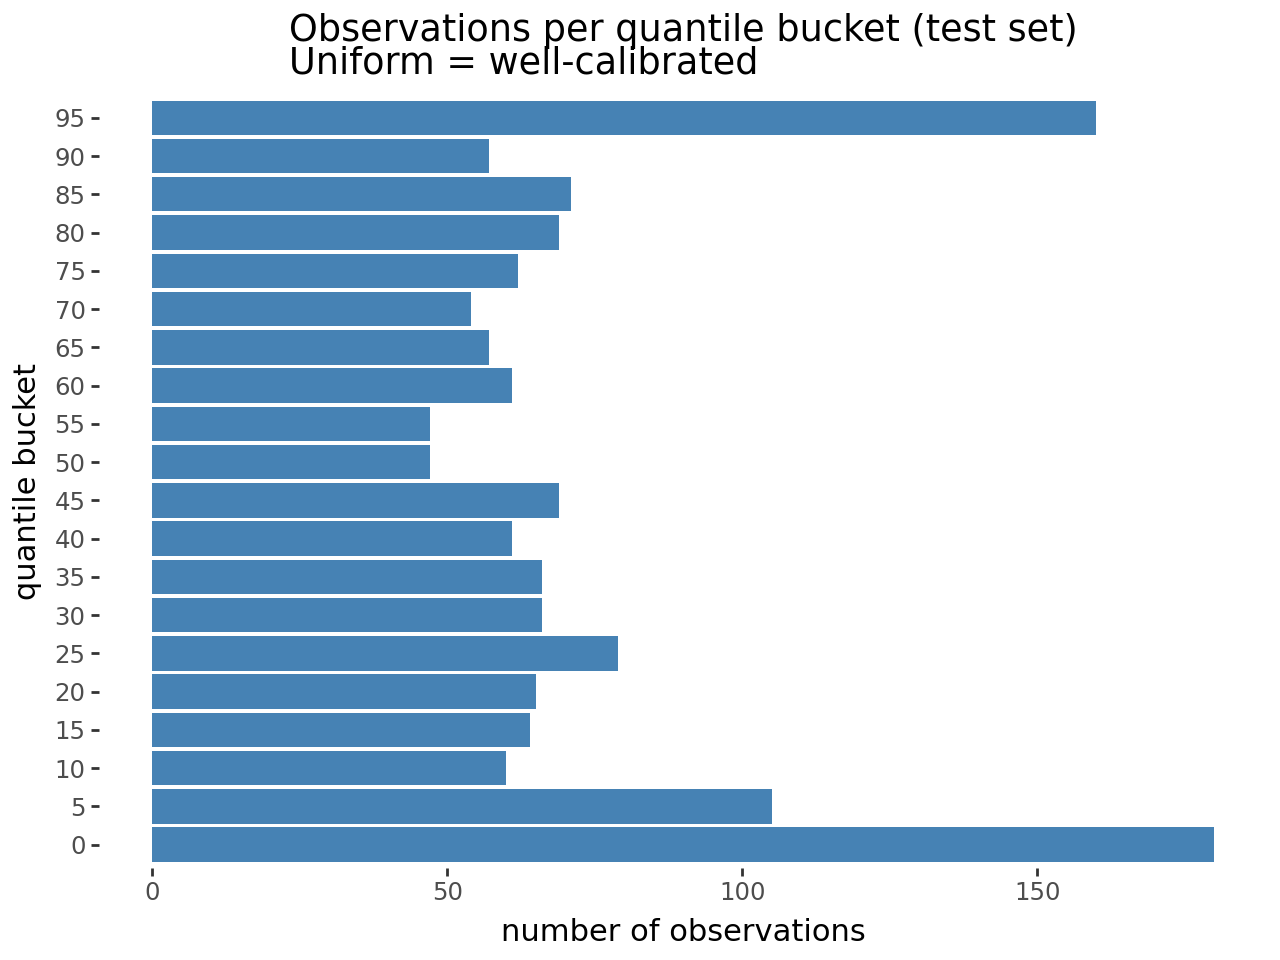

In [4]:
def assign_quantile_bucket(y_true, preds_df, q_labels):
    bucket = pd.Series(['0'] * len(y_true), index=preds_df.index)
    for col in q_labels:
        bucket[y_true >= preds_df[col].values] = col[1:]   # strip 'q' prefix
    return bucket

X_test = X_test.copy().reset_index(drop=True)
preds_df = preds_df.reset_index(drop=True)
X_test['bucket'] = assign_quantile_bucket(y_test, preds_df, q_labels)

# Ordered categorical for correct x-axis sort
bucket_order  = ['0'] + [l[1:] for l in q_labels]
X_test['bucket_cat'] = pd.Categorical(X_test['bucket'], categories=bucket_order)

(ggplot(X_test, aes(x='bucket_cat'))
 + geom_bar(fill='steelblue')
 + coord_flip()
 + theme(panel_background=element_rect(fill='white'), panel_grid_minor=element_blank())
 + labs(x='quantile bucket', y='number of observations',
        title='Observations per quantile bucket (test set)\nUniform = well-calibrated')
)

## 4. Cumulative Calibration Curve

Plot the actual empirical coverage (fraction of observations below each
predicted quantile) against the nominal quantile level.
The dashed diagonal is the target — perfect calibration.

Mean absolute calibration error: 0.0483
 nominal   actual    error
    0.05 0.120000 0.070000
    0.10 0.190000 0.090000
    0.15 0.230000 0.080000
    0.20 0.272667 0.072667
    0.25 0.316000 0.066000
    0.30 0.368667 0.068667
    0.35 0.412667 0.062667
    0.40 0.456667 0.056667
    0.45 0.497333 0.047333
    0.50 0.543333 0.043333
    0.55 0.574667 0.024667
    0.60 0.606000 0.006000
    0.65 0.646667 0.003333
    0.70 0.684667 0.015333
    0.75 0.720667 0.029333
    0.80 0.762000 0.038000
    0.85 0.808000 0.042000
    0.90 0.855333 0.044667
    0.95 0.893333 0.056667


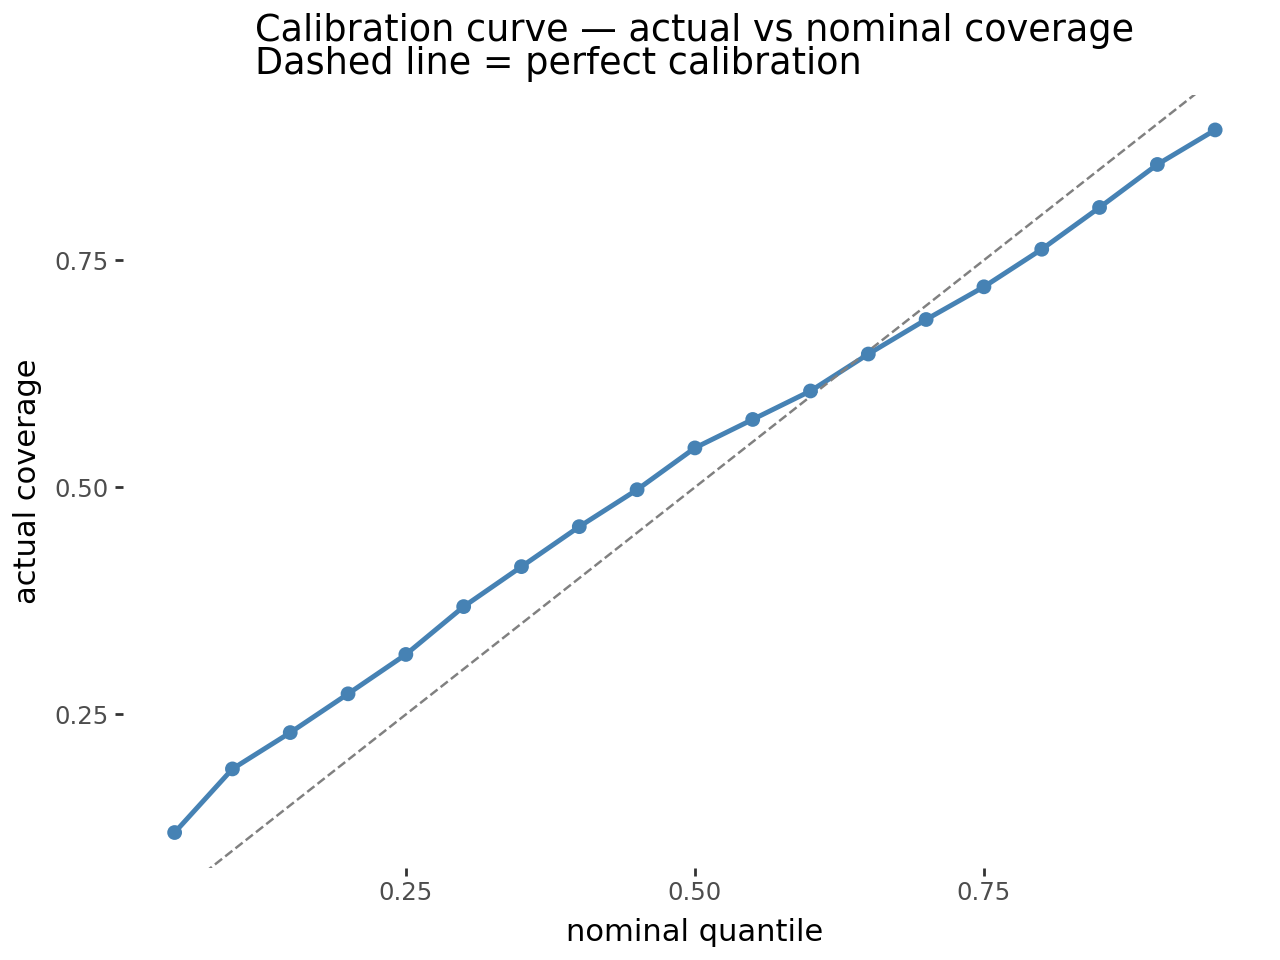

In [5]:
actual_coverage = [(y_test < preds[:, i]).mean() for i in range(len(alphas))]

calib = pd.DataFrame({
    'nominal':  alphas,
    'actual':   actual_coverage,
    'error':    [abs(a - n) for a, n in zip(actual_coverage, alphas)],
})

print(f"Mean absolute calibration error: {calib['error'].mean():.4f}")
print(calib.to_string(index=False))

(ggplot(calib, aes(x='nominal', y='actual'))
 + geom_line(color='steelblue', size=1)
 + geom_abline(slope=1, intercept=0, linetype='dashed', color='gray')
 + geom_point(color='steelblue', size=2)
 + theme(panel_background=element_rect(fill='white'), panel_grid_minor=element_blank())
 + labs(x='nominal quantile', y='actual coverage',
        title='Calibration curve — actual vs nominal coverage\nDashed line = perfect calibration')
)